# **Mini-Project 1**

### Load + Understanding

In [36]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.shape
df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


### Data Quality & Cleaning

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [39]:
df["customerID"].duplicated().sum()

np.int64(0)

In [40]:
df["TotalCharges"].value_counts().head(10)

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
19.65,8
19.55,7
45.3,7
20.15,6


In [41]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [42]:
df[df["TotalCharges"].str.strip() == ""][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [43]:
# from "" to 0
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [44]:
df["TotalCharges"].dtype

dtype('float64')

In [45]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [46]:
df["tenure"].min(), df["tenure"].max()

(0, 72)

In [47]:
df["MonthlyCharges"].min(), df["MonthlyCharges"].max()

(18.25, 118.75)

In [48]:
df["TotalCharges"].min(), df["TotalCharges"].max()

(0.0, 8684.8)

### EDA

In [49]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [50]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [51]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


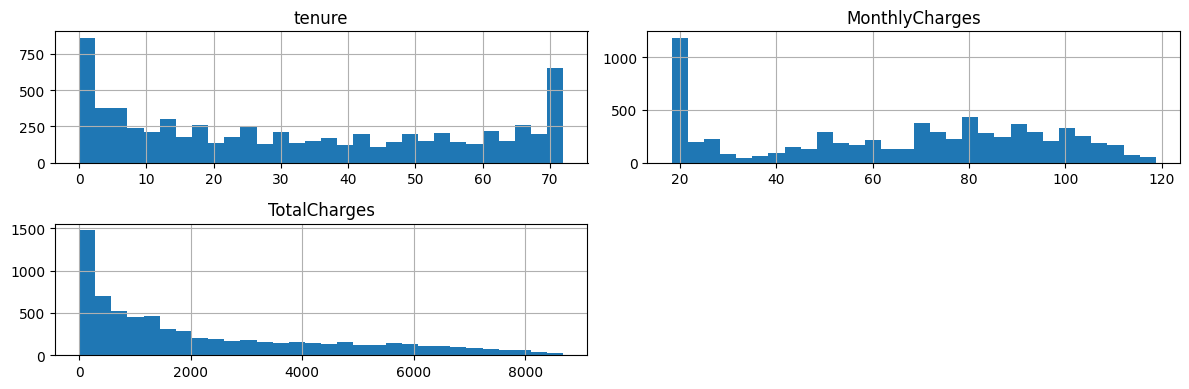

In [52]:
import matplotlib.pyplot as plt

df[["tenure", "MonthlyCharges", "TotalCharges"]].hist(
    figsize=(12, 4),
    bins=30
)

plt.tight_layout()
plt.show()

In [53]:
# cate distribution
categorical_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Contract
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


In [54]:
churn_by_contract = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values())

churn_by_contract

,Churn
Contract,
Two year,2.831858
One year,11.269518
Month-to-month,42.709677


In [55]:
churn_by_internet = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

churn_by_internet

,Churn
InternetService,
Fiber optic,41.892765
DSL,18.959108
No,7.404980


In [56]:
churn_by_payment = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

churn_by_payment

,Churn
PaymentMethod,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


In [57]:
churn_by_senior = (
    df.groupby("SeniorCitizen")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False))

churn_by_senior

,Churn
SeniorCitizen,
1,41.681261
0,23.606168


In [58]:
df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr(numeric_only=True)

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


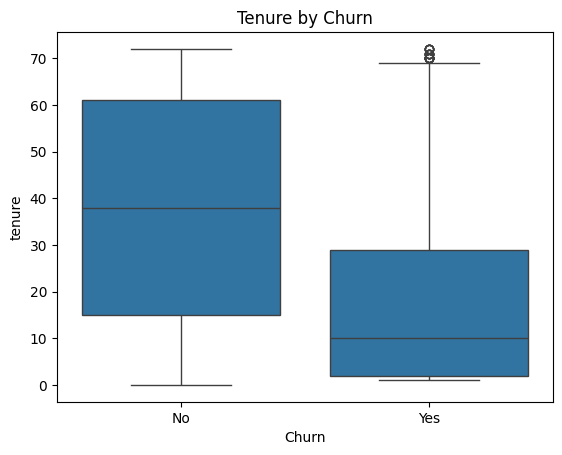

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.show()

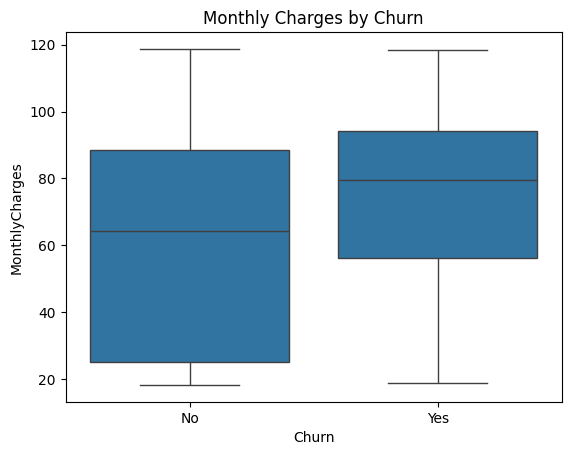

In [60]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

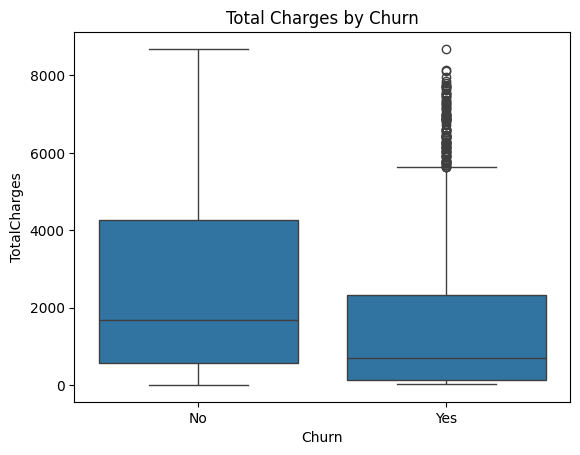

In [61]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn")
plt.show()

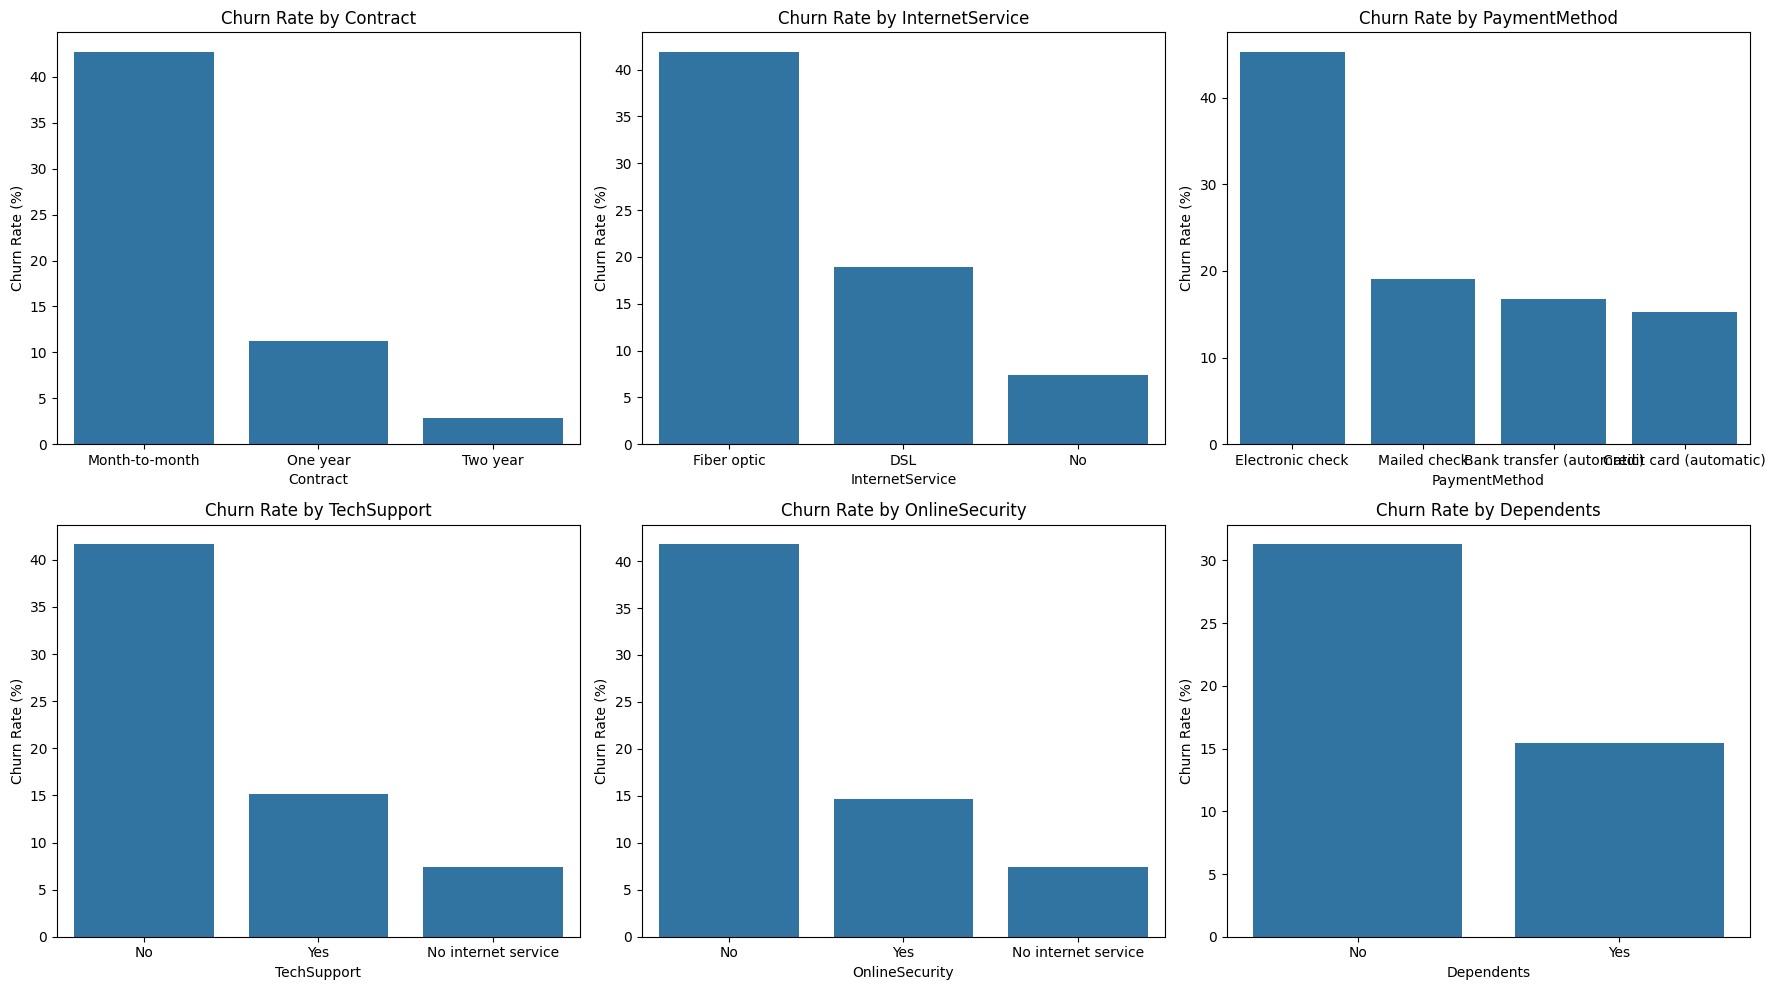

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "Dependents"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, categorical_cols):

    churn_rate = (
        df.groupby(col)["Churn"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
    )

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values,
        ax=ax
    )

    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

### Feature Engineering

##### Classify

In [63]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [64]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


##### Binary Encoding

In [65]:
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

df[binary_cols] = df[binary_cols].replace({
    "Yes": 1,
    "No": 0
})

df[binary_cols].head()

/tmp/ipykernel_1020/1475330450.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


,Partner,Dependents,PhoneService,PaperlessBilling
0,1,0,0,1
1,0,0,1,0
2,0,0,1,1
3,0,0,0,0
4,0,0,1,1


In [66]:
df["gender"] = df["gender"].map({
    "Male": 1,
    "Female": 0
})

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


##### Multi Encoding

In [67]:
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

df = pd.get_dummies(
    df,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,0,0,0,0,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,0,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,0,0,0,0,0,0,0,0,1,0
5,9305-CDSKC,0,0,0,0,8,1,1,99.65,820.50,...,0,0,1,0,1,0,0,0,1,0
6,1452-KIOVK,1,0,0,1,22,1,1,89.10,1949.40,...,0,0,1,0,0,0,0,1,0,0
7,6713-OKOMC,0,0,0,0,10,0,0,29.75,301.90,...,0,0,0,0,0,0,0,0,0,1
8,7892-POOKP,0,0,1,0,28,1,1,104.80,3046.05,...,1,0,1,0,1,0,0,0,1,0
9,6388-TABGU,1,0,0,1,62,1,0,56.15,3487.95,...,0,0,0,0,0,1,0,0,0,0


##### Features

In [69]:
service_cols = [
    "OnlineSecurity_Yes",
    "OnlineBackup_Yes",
    "DeviceProtection_Yes",
    "TechSupport_Yes",
    "StreamingTV_Yes",
    "StreamingMovies_Yes"
]

df["TotalServices"] = df[service_cols].sum(axis=1)

df[["TotalServices", "Churn"]].head(10)

,TotalServices,Churn
0,1,0
1,2,0
2,2,1
3,3,0
4,0,1
5,3,1
6,2,0
7,1,0
8,4,1
9,2,0


In [70]:
df["IsNewCustomer"] = (df["tenure"] <= 12).astype(int)

df[["tenure", "IsNewCustomer", "Churn"]].head(10)

,tenure,IsNewCustomer,Churn
0,1,1,0
1,34,0,0
2,2,1,1
3,45,0,0
4,2,1,1
5,8,1,1
6,22,0,0
7,10,1,0
8,28,0,1
9,62,0,0


In [71]:
df["AvgMonthlySpend"] = (
    df["TotalCharges"] / df["tenure"].replace(0, 1)
)

df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend"
]].head(10)

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000
5,8,99.65,820.50,102.562500
6,22,89.10,1949.40,88.609091
7,10,29.75,301.90,30.190000
8,28,104.80,3046.05,108.787500
9,62,56.15,3487.95,56.257258


In [72]:
df["ChargeGap"] = df["MonthlyCharges"] - df["AvgMonthlySpend"]

df[[
    "MonthlyCharges",
    "AvgMonthlySpend",
    "ChargeGap"
]].head(10)

,MonthlyCharges,AvgMonthlySpend,ChargeGap
0,29.85,29.850000,0.000000
1,56.95,55.573529,1.376471
2,53.85,54.075000,-0.225000
3,42.30,40.905556,1.394444
4,70.70,75.825000,-5.125000
5,99.65,102.562500,-2.912500
6,89.10,88.609091,0.490909
7,29.75,30.190000,-0.440000
8,104.80,108.787500,-3.987500
9,56.15,56.257258,-0.107258


In [73]:
df[[
    "TotalServices",
    "IsNewCustomer",
    "AvgMonthlySpend",
    "ChargeGap"
]].describe()

,TotalServices,IsNewCustomer,AvgMonthlySpend,ChargeGap
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,2.037910,0.310379,64.698218,0.063475
std,1.847682,0.462682,30.270670,3.211815
min,0.000000,0.000000,0.000000,-18.900000
25%,0.000000,0.000000,35.649000,-1.159091
50%,2.000000,0.000000,70.300000,0.000000
75%,3.000000,1.000000,90.174158,1.154880
max,6.000000,1.000000,121.400000,80.850000


### Customer Segmentation

In [74]:
segmentation_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalServices"
]

segmentation_df = df[segmentation_features].copy()

segmentation_df.head()

,tenure,MonthlyCharges,TotalCharges,TotalServices
0,1,29.85,29.85,1
1,34,56.95,1889.50,2
2,2,53.85,108.15,2
3,45,42.30,1840.75,3
4,2,70.70,151.65,0


In [75]:
segmentation_df.describe()

,tenure,MonthlyCharges,TotalCharges,TotalServices
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.037910
std,24.559481,30.090047,2266.794470,1.847682
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000
50%,29.000000,70.350000,1394.550000,2.000000
75%,55.000000,89.850000,3786.600000,3.000000
max,72.000000,118.750000,8684.800000,6.000000


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

segmentation_scaled = scaler.fit_transform(segmentation_df)

segmentation_scaled = pd.DataFrame(
    segmentation_scaled,
    columns=segmentation_features,
    index=segmentation_df.index
)

segmentation_scaled.head()

,tenure,MonthlyCharges,TotalCharges,TotalServices
0,-1.277445,-1.160323,-0.992611,-0.561776
1,0.066327,-0.259629,-0.172165,-0.020519
2,-1.236724,-0.362660,-0.958066,-0.020519
3,0.514251,-0.746535,-0.193672,0.520738
4,-1.236724,0.197365,-0.938874,-1.103033


In [78]:
# Interactive visualization of K-Means clusters

from sklearn.decomposition import PCA
import plotly.express as px

# Reduce 4 features to 2 dimensions for visualization
pca = PCA(n_components=2)

pca_data = pca.fit_transform(segmentation_scaled)

plot_df = pd.DataFrame({
    "PCA1": pca_data[:, 0],
    "PCA2": pca_data[:, 1],
    "Segment": segmentation_df["Segment"].astype(str),
    "Tenure": segmentation_df["tenure"],
    "MonthlyCharges": segmentation_df["MonthlyCharges"],
    "TotalCharges": segmentation_df["TotalCharges"]
})

# Interactive scatter plot
fig = px.scatter(
    plot_df,
    x="PCA1",
    y="PCA2",
    color="Segment",
    hover_data=[
        "Tenure",
        "MonthlyCharges",
        "TotalCharges"
    ],
    title="Interactive Customer Segmentation using K-Means",
    labels={
        "PCA1": "PCA Dimension 1",
        "PCA2": "PCA Dimension 2"
    }
)

fig.show()

### Save data

In [79]:
# Save the final dataset
df.to_csv("data after py.csv", index=False)
